In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [2]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from  src.model_siamese import SiameseUNet
from torch.amp import GradScaler

scaler = GradScaler('cuda')

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [4]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 4
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 15
BASE_FEATURES = 24
SAVE_PATH = "best_siamese_unet_combo.pth"

In [5]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=True, augment_train=True)

In [7]:
# Sanity check
pre, post, masks = next(iter(train_loader))

print(f"Pre image:  {pre.shape}")    # [B, 3, H, W]
print(f"Post image: {post.shape}")   # [B, 3, H, W]
print(f"Masks:      {masks.shape}")  # [B, H, W]
print(f"Mask range: {masks.min()} – {masks.max()}")
print(f"Device:     {pre.device}")

Pre image:  torch.Size([4, 3, 512, 512])
Post image: torch.Size([4, 3, 512, 512])
Masks:      torch.Size([4, 512, 512])
Mask range: 0 – 4
Device:     cpu


In [8]:
# Inverse Effective Weight
beta = 0.9999
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

effective_num = (1.0 - beta**class_counts) / (1.0 - beta)
weights = 1.0 / effective_num 
weights = weights / weights.min()
class_weights = weights.to(device) 

In [9]:
# Model
model = SiameseUNet(
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES,
    in_channels=3 # only include 3 channels for Siamese
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device)

Model parameters: 5,839,277
cuda:0


In [10]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.85, tversky_beta=0.15, tversky_gamma=0.6,
                      ohem_keep_ratio = 0.7,
                      num_classes=NUM_CLASSES).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay = 1e-4)

#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1, div_factor=10, final_div_factor=100)

In [11]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True,
    siamese = True, scaler=scaler)

c:\Dev\Damage_Assessment_on_xBD\src\eval.py:65: RuntimeWarning: invalid value encountered in divide
  precision = np.where(denom_prec > 0, TP / denom_prec, np.nan)
c:\Dev\Damage_Assessment_on_xBD\src\eval.py:78: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall),



Epoch 1/50  (lr=2.00e-05)
  Train Loss: 0.9840  |  Val Loss: 0.8263
  Train mIoU: 0.2210  |  Val mIoU: 0.2692
  Train Acc:  0.8109  |  Val Acc:  0.9484
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9477   0.9855   0.9611
    Minor             0.3983   0.4677   0.7285
    Major             0.0000   0.0000   0.0000
    Destroyed         0.0000      nan   0.0000
    Unclassified      0.0000   0.1557   0.0000
  *** Saved new best model (mIoU=0.2692) ***


  *** Saved new best model (mIoU=0.3340) ***


  *** Saved new best model (mIoU=0.3649) ***


  *** Saved new best model (mIoU=0.3940) ***


...

  *** Saved new best model (mIoU=0.4384) ***



Epoch 35/50  (lr=5.63e-05)
  Train Loss: 0.4328  |  Val Loss: 0.5071
  Train mIoU: 0.5828  |  Val mIoU: 0.4305
  Train Acc:  0.9644  |  Val Acc:  0.9778
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9785   0.9899   0.9884
    Minor             0.6368   0.7750   0.7813
    Major             0.0051   0.0056   0.0649
    Destroyed         0.0649   0.0804   0.2515
    Unclassified      0.4675   0.7378   0.5606



Epoch 40/50  (lr=2.82e-05)
  Train Loss: 0.4266  |  Val Loss: 0.5074
  Train mIoU: 0.6058  |  Val mIoU: 0.4246
  Train Acc:  0.9656  |  Val Acc:  0.9771
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9776   0.9906   0.9868
    Minor             0.6359   0.7576   0.7983
    Major             0.0070   0.0075   0.0965
    Destroyed         0.0398   0.0514   0.1497
    Unclassified      0.4627   0.7439   0.5503



Epoch 45/50  (lr=8.84e-06)
  Train Loss: 0.4216  |  Val Loss: 0.5050
  Train mIoU: 0.6115  |  Val mIoU: 0.4313
  Train Acc:  0.9664  |  Val Acc:  0.9778
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9779   0.9902   0.9875
    Minor             0.6401   0.7628   0.7992
    Major             0.0038   0.0043   0.0275
    Destroyed         0.0561   0.0713   0.2081
    Unclassified      0.4788   0.7585   0.5649



Early stopping triggered after 49 epochs.


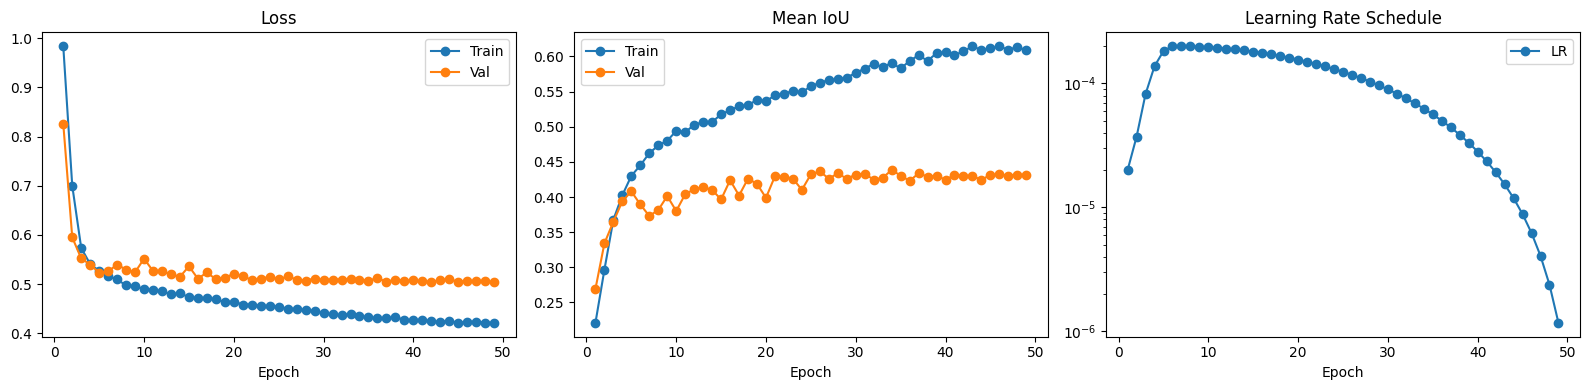

In [12]:
plot_train_history(history)

In [13]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=True)

Test Loss: 0.6581
Test mIoU: 0.3174
Test Acc:  0.9223

Class                IoU     Prec   Recall
No Damage         0.9427   0.9591   0.9822
Minor             0.5808   0.7083   0.7634
Major             0.0190   0.0851   0.0238
Destroyed         0.0134   0.2563   0.0140
Unclassified      0.0311   0.1535   0.0376
